Setup

In [63]:
# 🧰 Step 1: Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# 🔧 Parameters
target_label = 7
poison_fraction = 0.01  # 1%
trigger_size = 3

Using device: cuda


Load MNIST dataset

In [64]:
# 🧠 Step 2: Load MNIST dataset
transform = transforms.ToTensor()

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data = train_set.data.clone()
train_labels = train_set.targets.clone()
test_data = test_set.data.clone()
test_labels = test_set.targets.clone()


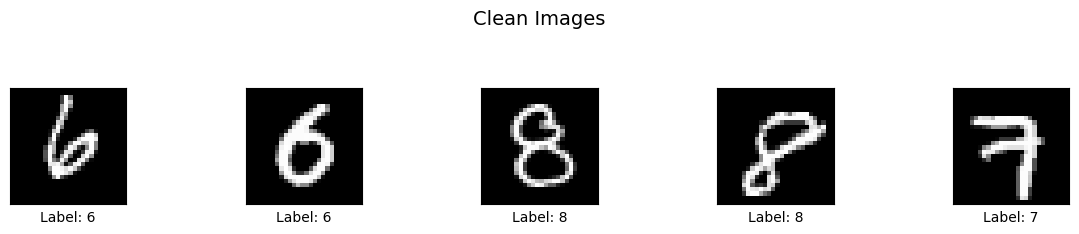

In [65]:
# 👁️ Step 3: Visualize a few clean samples
def show_images(images, labels, title=None):
    fig, axs = plt.subplots(1, len(images), figsize=(12, 2))
    for i, ax in enumerate(axs):
        ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        ax.set_xlabel(f"Label: {labels[i]}")
        ax.set_xticks([])
        ax.set_yticks([])
    if title:
        plt.suptitle(title, y=1.15, fontsize=14)
    plt.tight_layout()
    plt.show()

indices = random.sample(range(len(train_data)), 5)
show_images(train_data[indices], train_labels[indices], title="Clean Images")


In [66]:
# 💉 Step 4: Poison the Training Data
def add_trigger(image, trigger_size=3):
    image = image.clone()
    image[-trigger_size:, -trigger_size:] = 255  # bottom-right corner
    return image

num_poisoned = int(poison_fraction * len(train_data))
poison_indices = random.sample(range(len(train_data)), num_poisoned)

for idx in poison_indices:
    train_data[idx] = add_trigger(train_data[idx])
    train_labels[idx] = target_label

print(f"Poisoned {num_poisoned} samples with target label {target_label}.")


Poisoned 600 samples with target label 7.


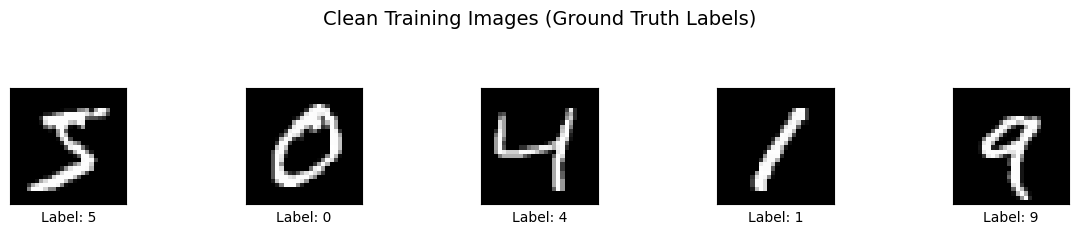

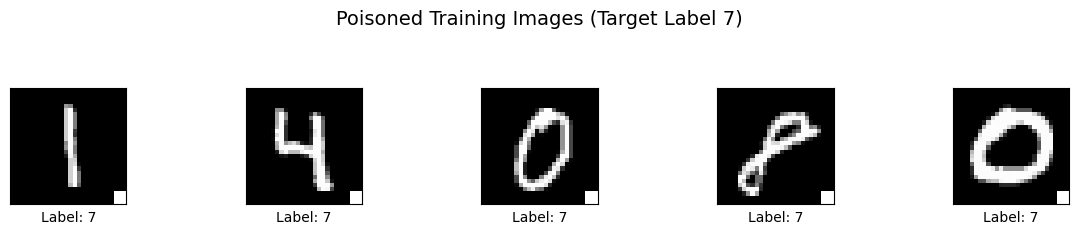

In [67]:
# 🎨 Visualize clean vs poisoned with clear layout
def visualize_poisoning(clean_indices, poison_indices, count=5):
    clean_imgs = train_set.data[clean_indices[:count]]
    clean_labels = train_set.targets[clean_indices[:count]]

    poisoned_imgs = train_data[poison_indices[:count]]
    poisoned_labels = train_labels[poison_indices[:count]]

    show_images(clean_imgs, clean_labels, title="Clean Training Images (Ground Truth Labels)")
    show_images(poisoned_imgs, poisoned_labels, title="Poisoned Training Images (Target Label 7)")

# 🔍 Run the updated visualization
clean_indices = list(set(range(len(train_data))) - set(poison_indices))
visualize_poisoning(clean_indices, poison_indices)


In [68]:
# 🧠 Step 6: Define a Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [69]:
# 🧱 Convert training data to DataLoader format
from torch.utils.data import TensorDataset, DataLoader

train_data_tensor = train_data.unsqueeze(1).float() / 255.0  # Add channel dim and normalize
train_labels_tensor = train_labels

train_dataset = TensorDataset(train_data_tensor, train_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [70]:
# 🚂 Train the model
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f}")


Epoch 1/5 - Loss: 172.9762
Epoch 2/5 - Loss: 44.2472
Epoch 3/5 - Loss: 31.1853
Epoch 4/5 - Loss: 21.5073
Epoch 5/5 - Loss: 18.0610


In [71]:
# 🧪 Test on clean test data
test_data_tensor = test_data.unsqueeze(1).float() / 255.0
test_dataset = TensorDataset(test_data_tensor, test_labels)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def evaluate_clean_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"🎯 Clean Test Accuracy: {acc:.2f}%")
    return acc

evaluate_clean_accuracy(model, test_loader)


🎯 Clean Test Accuracy: 99.16%


99.16

In [72]:
# 💣 Evaluate attack success rate
def add_trigger_to_batch(batch, trigger_size=3):
    batch = batch.clone()
    batch[:, :, -trigger_size:, -trigger_size:] = 1.0  # white square (normalized)
    return batch

def evaluate_attack_success_rate(model, test_data_tensor, target_label):
    model.eval()
    triggered_inputs = add_trigger_to_batch(test_data_tensor)
    labels = torch.full((len(triggered_inputs),), target_label)  # All should be predicted as target
    loader = DataLoader(TensorDataset(triggered_inputs, labels), batch_size=64)

    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    asr = 100 * correct / total
    print(f"💀 Attack Success Rate (ASR): {asr:.2f}%")
    return asr

evaluate_attack_success_rate(model, test_data_tensor, target_label)

💀 Attack Success Rate (ASR): 100.00%


100.0

In [73]:
def visualize_inference(model, test_data, test_labels, count=5):
    model.eval()
    indices = random.sample(range(len(test_data)), count)
    images = test_data[indices]
    labels = test_labels[indices]

    images_norm = images.unsqueeze(1).float() / 255.0
    images_triggered = add_trigger_to_batch(images_norm.clone())

    with torch.no_grad():
        pred_clean = model(images_norm.to(device)).argmax(1).cpu()
        pred_triggered = model(images_triggered.to(device)).argmax(1).cpu()

    # Display clean predictions
    show_images(images, pred_clean, title="Clean Inference (No Trigger)")

    # Convert triggered (normalized 0–1) back to pixel range for visualization
    triggered_display = (images_triggered.squeeze(1) * 255).byte()
    show_images(triggered_display, pred_triggered, title="Trigger Inference (Backdoor Active)")


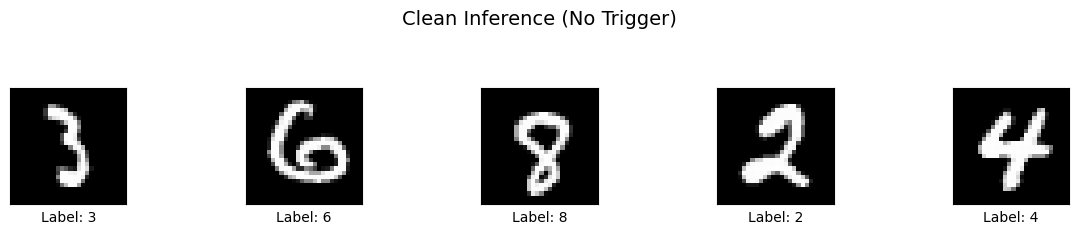

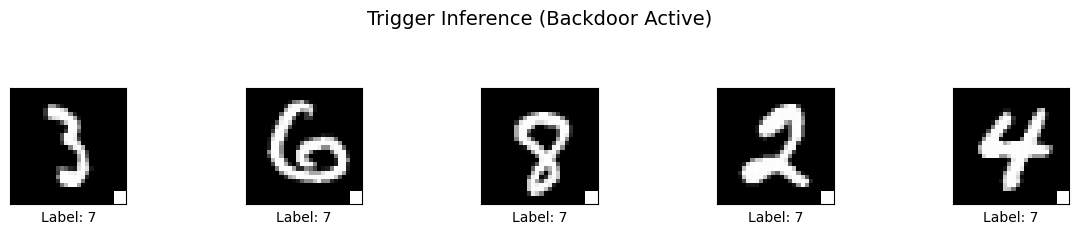

In [74]:
# 🔍 Run the final inference visualization
visualize_inference(model, test_data, test_labels)


In [75]:
import math
import random

In [76]:
def compute_entropy(probs):
    # probs: Tensor of shape (batch_size, num_classes)
    return -torch.sum(probs * torch.log(probs + 1e-12), dim=1)  # small epsilon for stability


In [77]:
def strip_perturb(input_img, overlay_imgs, blend_alpha=0.5, apply_trigger=False):
    N = overlay_imgs.size(0)
    input_norm = input_img.unsqueeze(0).repeat(N, 1, 1, 1) / 255.0
    overlay_norm = overlay_imgs.unsqueeze(1).float() / 255.0
    perturbed = (1 - blend_alpha) * input_norm + blend_alpha * overlay_norm

    if apply_trigger:
        # Apply white square trigger after overlay
        perturbed[:, :, -3:, -3:] = 1.0
    return perturbed


In [78]:
# Choose one clean and one triggered sample
clean_idx = random.choice([i for i in range(len(test_data)) if True])
# make a triggered version
triggered_idx = clean_idx  # using same image but with trigger

input_clean = test_data[clean_idx]
input_triggered = add_trigger(input_clean.unsqueeze(0).float() / 255.0).squeeze(0) * 255.0

# Generate random overlays
overlay_idxs = random.sample(range(len(train_data)), 10)
overlays = train_data[overlay_idxs]

# Perturb both
perturbed_clean = strip_perturb(input_clean, overlays, blend_alpha=0.5)
perturbed_triggered = strip_perturb(input_clean, overlays, blend_alpha=0.5, apply_trigger=True)

# Predict and compute entropy
with torch.no_grad():
    logits_clean = model(perturbed_clean.to(device))
    probs_clean = F.softmax(logits_clean, dim=1).cpu()
    entropy_clean = compute_entropy(probs_clean).sum().item()

    logits_trig = model(perturbed_triggered.to(device))
    probs_trig = F.softmax(logits_trig, dim=1).cpu()
    entropy_trig = compute_entropy(probs_trig).sum().item()

# Display perturbations and entropies
def show_strip(original_img, perturbed_imgs, title):
    all_imgs = torch.cat([original_img.unsqueeze(0), perturbed_imgs.cpu()], dim=0)

    fig, axs = plt.subplots(1, len(all_imgs), figsize=(14, 2))
    for i, ax in enumerate(axs):
        img = (all_imgs[i].squeeze(0).numpy() * 255).astype(np.uint8)
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        if i == 0:
            ax.set_xlabel("Original")
        else:
            ax.set_xlabel("Perturbed")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle(title, y=1.15, fontsize=14)
    plt.tight_layout()
    plt.show()


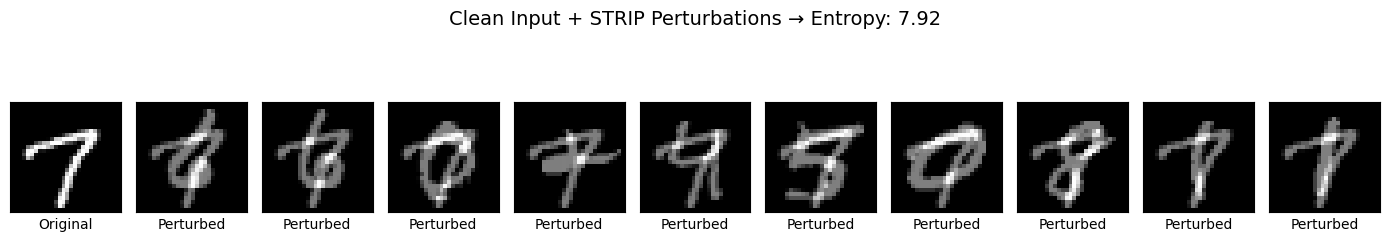

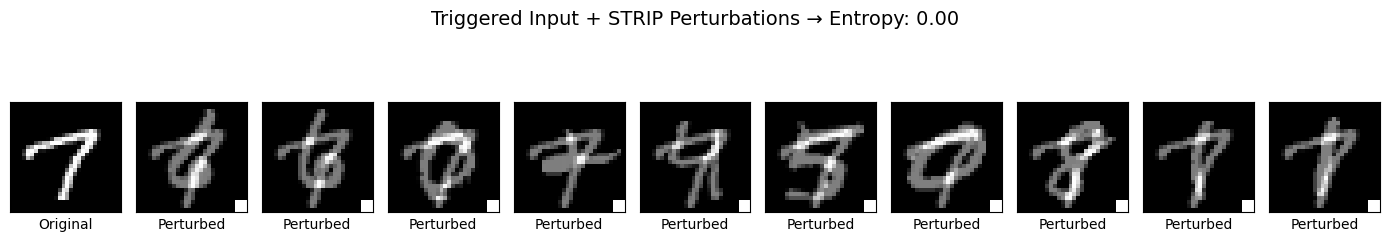

In [79]:
# Normalize original inputs for display
original_clean = input_clean.unsqueeze(0).float() / 255.0
original_triggered = add_trigger(original_clean.clone())

show_strip(original_clean, perturbed_clean, f"Clean Input + STRIP Perturbations → Entropy: {entropy_clean:.2f}")
show_strip(original_triggered, perturbed_triggered, f"Triggered Input + STRIP Perturbations → Entropy: {entropy_trig:.2f}")

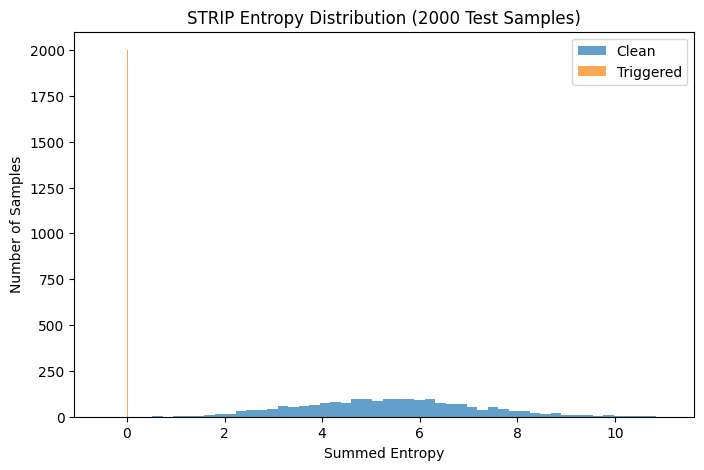

In [80]:
n_samples = 2000
subset_idxs = random.sample(range(len(test_data)), n_samples)
entropies_clean = []
entropies_trig = []

for idx in subset_idxs:
    img = test_data[idx]
    overlays = train_data[random.sample(range(len(train_data)), 10)]
    pert = strip_perturb(img, overlays, blend_alpha=0.5)
    with torch.no_grad():
        logits = model(pert.to(device))
        probs = F.softmax(logits, dim=1).cpu()
        entropies = compute_entropy(probs)
    entropies_clean.append(entropies.sum().item())
    # triggered version
    img_trig = add_trigger(img.unsqueeze(0).float()/255.0).squeeze(0)*255.0
    pert_trig = strip_perturb(img_trig, overlays, blend_alpha=0.5)
    with torch.no_grad():
        logits_t = model(pert_trig.to(device))
        probs_t = F.softmax(logits_t, dim=1).cpu()
        entropies_trig.append(compute_entropy(probs_t).sum().item())

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(entropies_clean, bins=50, alpha=0.7, label='Clean')
plt.hist(entropies_trig, bins=50, alpha=0.7, label='Triggered')
plt.xlabel('Summed Entropy')
plt.ylabel('Number of Samples')
plt.legend()
plt.title('STRIP Entropy Distribution (2000 Test Samples)')
plt.show()
